## EDA and Feature engineering on Uber dataset

Dataset link: https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard?select=ncr_ride_bookings.csv

### Objective
+ To understand the customer behaviour 
+ Driver and customer relation
+ Driver behaviour 
+ Reasons for incomplete ride

#### Importing require packages

In [121]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/bhaskarrai/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/bhaskarrai/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/bhaskarrai/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/bhaskarrai/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### Dataset loading and basic overview

In [122]:
df = pd.read_csv("./data/ncr_ride_bookings.csv")

In [123]:
df.shape 

(150000, 21)

In [124]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [125]:
df.tail()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI
149999,2024-03-10,15:38:03,"""CNR3447390""",Completed,"""CID4108667""",Premier Sedan,Ashok Park Main,Gurgaon Sector 29,3.5,33.7,...,NaN,NaN,NaN,NaN,NaN,806.0,21.19,4.6,4.9,Credit Card


In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10500 non-null 

In [127]:
df.columns


Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='str')

In [128]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [129]:
df.duplicated().sum()
# no duplicates

np.int64(0)

### Univariant analysis 

#### Cancelled Rides by Customer

#### Reasons for cancelation of ride by customer 
+ 10500 rides are cancel by customer
+ On average each cancelation message contain 22 words 
+ Maximum ride cancle is due to the driver not moving towards the pickup location
+ Another reasons is also ac not working in rider vechiles
+ Some ride is cancel due to the driver ask for cancelation 

In [130]:
total_null_value = df["Cancelled Rides by Customer"].isnull().sum()
dataset_len = df.shape[0] 

total_number_of_cancelation = dataset_len - total_null_value
print("Total cancelation:",total_number_of_cancelation)

Total cancelation: 10500


In [131]:
# only dataset cancle by customer
customer_cancle_df = df.loc[df["Cancelled Rides by Customer"].isnull()  == False]
customer_cancle_df.head(2)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
18,2024-11-24,09:07:10,"""CNR6126048""",Cancelled by Customer,"""CID1060329""",eBike,Kashmere Gate,Anand Vihar,12.4,NaN,...,Driver is not moving towards pickup location,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,2024-09-10,13:02:42,"""CNR4218487""",Cancelled by Customer,"""CID3037053""",Bike,Noida Extension,Udyog Vihar Phase 4,11.0,NaN,...,Driver is not moving towards pickup location,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [132]:
paragraph_len = []
customer_cancle_column = customer_cancle_df["Reason for cancelling by Customer"]
for cancle_message in customer_cancle_column:
    paragraph_len.append(len(cancle_message))

# Stat  
pd.DataFrame(paragraph_len).describe()

,0
count,10500.000000
mean,22.749143
std,11.791362
min,13.000000
25%,15.000000
50%,17.000000
75%,22.000000
max,44.000000


#### Cleaning the text 

In [133]:
# customizing stop words
stop_words = stopwords.words("english")
remove_words  = ["not","no"]
updated_stop_words = [word for word in stop_words if word not in remove_words]

In [134]:
# converting into token
def sentence_convert_into_token(data:list)->list:
    tokens  = []
    for sentence in data:
        token = word_tokenize(sentence.strip())
        tokens.append(token)
    return tokens


In [135]:
# ngram implementation
def text_vectorize(text,n):
    ngram  = []
    for token in text:
        sentence = []
        for i in range(len(token)-n+1):
            gram = token[i:i+n]
            sentence.append(" ".join(gram))

        ngram.append(sentence)
            
    return ngram 

In [ ]:
# calculate word frequency 
def word_frequency(text):
    word_freq = {}
    for sentence in text:
        for word in sentence:
            if word in word_freq:
                word_freq[word] += 1
            else:
                word_freq[word] = 1
    return word_freq

In [160]:
tokens = sentence_convert_into_token(customer_cancle_column)
ngram = text_vectorize(tokens,3)
word_freq_dict = word_frequency(ngram)
word_freq_dict

{'Driver is not': 2335,
 'is not moving': 2335,
 'not moving towards': 2335,
 'moving towards pickup': 2335,
 'towards pickup location': 2335,
 'Driver asked to': 2295,
 'asked to cancel': 2295,
 'AC is not': 1155,
 'is not working': 1155,
 'Change of plans': 2353}

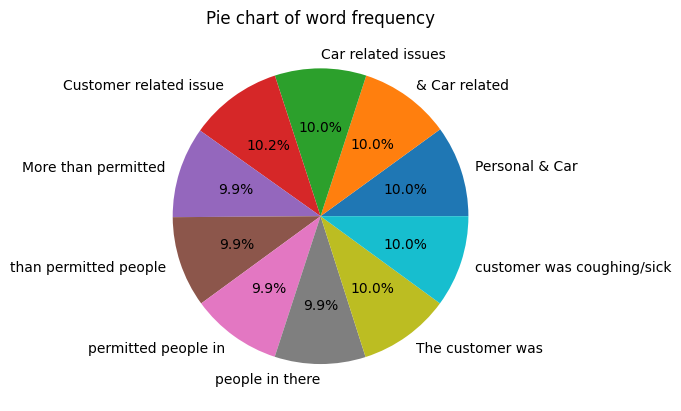

In [159]:
plt.title(f"Pie chart of word frequency")
plt.pie(x=word_freq_dict.values(),labels=word_freq_dict.keys(),autopct="%1.1f%%")
plt.show()

In [147]:
word_freq_df = pd.DataFrame(data=word_freq_dict.items(),columns=["words","frequency"])
word_freq_df

,words,frequency
0,Personal & Car,6726
1,& Car related,6726
2,Car related issues,6726
3,Customer related issue,6837
4,More than permitted,6686
5,than permitted people,6686
6,permitted people in,6686
7,people in there,6686
8,The customer was,6751
9,customer was coughing/sick,6751


### Cancelled Rides by Driver 

#### Reasons for cancelation of ride by driver
+ 27000 rides are cancle by driver 
+ Average lenght of the cancel message is 29 words 
+ Personal and car related issue lead to cancel the ride
+ More people at place then permited
+ Customer health issue  

In [152]:
total_null_value = df["Cancelled Rides by Driver"].isnull().sum()
dataset_len = df.shape[0] 

total_number_of_cancelation = dataset_len - total_null_value
print("Total ride cancelation by driver:",total_number_of_cancelation)

Total ride cancelation by driver: 27000


In [154]:
ride_cancelation_by_driver = df.loc[df["Cancelled Rides by Driver"].isnull() == False]
ride_cancelation_by_driver.shape 

(27000, 21)

In [155]:
paragraph_len = []
ride_cancelation_driver_column = ride_cancelation_by_driver["Driver Cancellation Reason"]
for cancle_message in ride_cancelation_driver_column:
    paragraph_len.append(len(cancle_message))

# Stat  
pd.DataFrame(paragraph_len).describe()

,0
count,27000.000000
mean,28.963259
std,4.644571
min,22.000000
25%,22.000000
50%,29.000000
75%,30.000000
max,35.000000


In [161]:
tokens = sentence_convert_into_token(ride_cancelation_by_driver["Driver Cancellation Reason"])
ngram = text_vectorize(tokens,3)
word_freq_dict = word_frequency(ngram)
word_freq_dict

{'Personal & Car': 6726,
 '& Car related': 6726,
 'Car related issues': 6726,
 'Customer related issue': 6837,
 'More than permitted': 6686,
 'than permitted people': 6686,
 'permitted people in': 6686,
 'people in there': 6686,
 'The customer was': 6751,
 'customer was coughing/sick': 6751}

In [157]:
dict(sorted(word_freq_dict.items()))

{'& Car related': 6726,
 'Car related issues': 6726,
 'Customer related issue': 6837,
 'More than permitted': 6686,
 'Personal & Car': 6726,
 'The customer was': 6751,
 'customer was coughing/sick': 6751,
 'people in there': 6686,
 'permitted people in': 6686,
 'than permitted people': 6686}

In [100]:
df.columns 

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='str')